# Question 8

## Part 1: Loading Data

In [5]:
import pandas as pd


def load_email_data(file_path, delimiter=' '):
    data = []
    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split(delimiter)

            email_id = parts[0]
            label = parts[1]
            word_parts = parts[2:]
            word_freqs = {}
            for i in range(0, len(word_parts), 2):
                if i + 1 < len(word_parts):
                    word = word_parts[i]
                    freq = int(word_parts[i+1])
                    word_freqs[word] = freq

            data.append({
                'email_id': email_id,
                'label': label,
                'word_freqs': word_freqs
            })

    df = pd.DataFrame(data)
    df['label'] = df['label'].map({'ham': 0, 'spam': 1})
    return df


train_df = load_email_data('train')
test_df = load_email_data('test')

## Part 2: Calculating Priors:


In [6]:
label_probabilities = train_df['label'].value_counts(normalize=True)
print(label_probabilities)

label
1    0.573667
0    0.426333
Name: proportion, dtype: float64


here we can see prior probabilities $P(spam) = 0.5736$ and $P(ham) = 0.4263 $ based on the count of spam/ham emails divided by total emails

## Part 3:
Here we create Frequency of each word in spam emails and in ham emails($P(\omega_{i}|spam)$ and $P(\omega_{i}|ham)$), Then for calculating probabilities
we use also use m-estimate with m = $|Vocabulary|$ and p = $1/|Vocabulary|$ in this case the $mp = 1$ and it will be equivalent to laplace smoothing.

In [7]:
# 1. Determine Vocabulary
from collections import defaultdict
vocabulary = set()
for word_dict in train_df['word_freqs']:
    vocabulary.update(word_dict.keys())

vocab_size = len(vocabulary)


spam_word_counts = defaultdict(int)
ham_word_counts = defaultdict(int)
total_words_spam = 0
total_words_ham = 0

spam_df = train_df[train_df['label'] == 1]
ham_df = train_df[train_df['label'] == 0]

for word_dict in spam_df['word_freqs']:
    for word, freq in word_dict.items():
        spam_word_counts[word] += freq
        total_words_spam += freq

for word_dict in ham_df['word_freqs']:
    for word, freq in word_dict.items():
        ham_word_counts[word] += freq
        total_words_ham += freq

print(f"Total words in spam (n_spam): {total_words_spam}")
print(f"Total words in ham (n_ham): {total_words_ham}")

probs_spam = {}
probs_ham = {}

denom_spam = total_words_spam + vocab_size
denom_ham = total_words_ham + vocab_size

for word in vocabulary:
    ni_spam = spam_word_counts[word]
    probs_spam[word] = (ni_spam + 1) / denom_spam

    ni_ham = ham_word_counts[word]
    probs_ham[word] = (ni_ham + 1) / denom_ham

sorted_spam = sorted(probs_spam.items(),
                     key=lambda item: item[1], reverse=True)
sorted_ham = sorted(probs_ham.items(), key=lambda item: item[1], reverse=True)

print("\n--- Top 5 Most Likely Spam Words P(wi | spam) ---")
for word, prob in sorted_spam[:5]:
    print(f"{word}: {prob:.8f}")

print("\n--- Top 5 Most Likely Ham Words P(wi | ham) ---")
for word, prob in sorted_ham[:5]:
    print(f"{word}: {prob:.8f}")

Total words in spam (n_spam): 1655369
Total words in ham (n_ham): 1577820

--- Top 5 Most Likely Spam Words P(wi | spam) ---
enron: 0.03819439
a: 0.02361853
corp: 0.02173791
the: 0.02142518
to: 0.01968704

--- Top 5 Most Likely Ham Words P(wi | ham) ---
aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa: 0.04432171
enron: 0.04244372
the: 0.03316908
to: 0.02532968
a: 0.01773666


### Part 4:
Now for each email, we calculate $\log(P(spam | \omega))$ that would be sum of all $P(\omega_{i} | spam )$ $\times$ $P(spam)$


In [ ]:
import numpy as np
print("\n--- Classifying Test Data ---")

log_prior_ham = np.log(label_probabilities[0])
log_prior_spam = np.log(label_probabilities[1])

log_probs_ham = {word: np.log(prob) for word, prob in probs_ham.items()}
log_probs_spam = {word: np.log(prob) for word, prob in probs_spam.items()}


def classify_email(word_freqs, log_prior_h, log_prior_s, log_probs_h, log_probs_s, vocab):
    score_ham = log_prior_h
    score_spam = log_prior_s

    for word, freq in word_freqs.items():
        if word in vocab:
            score_ham += freq * log_probs_h[word]
            score_spam += freq * log_probs_s[word]

    return 1 if score_spam > score_ham else 0


--- Classifying Test Data ---


### Part 5: Varying m parameter

--- Varying m parameter ---
m = 1     | Accuracy: 90.20%
m = 10    | Accuracy: 90.20%
m = 100   | Accuracy: 90.20%
m = 1000  | Accuracy: 90.20%
m = 10000 | Accuracy: 90.40%
m = 100000.0 | Accuracy: 90.40%
m = 1000000.0 | Accuracy: 87.10%
m = 10000000.0 | Accuracy: 76.50%
m = 100000000.0 | Accuracy: 69.90%
m = 100000000000.0 | Accuracy: 58.10%

Plotting accuracies...


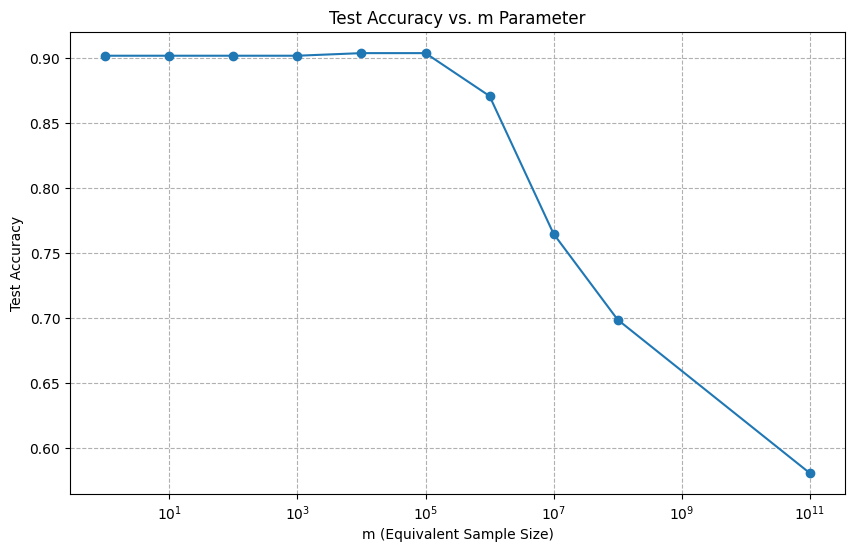

In [10]:
import matplotlib.pyplot as plt
print("--- Varying m parameter ---")

m_values = [1, 10, 100, 1000, 10000, 1e5, 1e6, 1e7, 1e8, 1e11]
p = 1 / vocab_size
accuracies = []

for m in m_values:
    probs_spam = {}
    probs_ham = {}

    mp = m * p

    denom_spam = total_words_spam + m
    denom_ham = total_words_ham + m

    for word in vocabulary:
        ni_spam = spam_word_counts[word]
        probs_spam[word] = (ni_spam + mp) / denom_spam

        ni_ham = ham_word_counts[word]
        probs_ham[word] = (ni_ham + mp) / denom_ham
    log_probs_ham = {word: np.log(prob) for word, prob in probs_ham.items()}
    log_probs_spam = {word: np.log(prob) for word, prob in probs_spam.items()}

    test_df['prediction'] = test_df['word_freqs'].apply(
        lambda freqs: classify_email(
            freqs, log_prior_ham, log_prior_spam, log_probs_ham, log_probs_spam, vocabulary
        )
    )
    correct_predictions = (test_df['prediction'] == test_df['label']).sum()
    total_predictions = len(test_df)
    accuracy = correct_predictions / total_predictions
    accuracies.append(accuracy)

    print(f"m = {m:<5} | Accuracy: {accuracy * 100:.2f}%")

print("\nPlotting accuracies...")
plt.figure(figsize=(10, 6))
plt.plot(m_values, accuracies, marker='o', linestyle='-')
plt.title('Test Accuracy vs. m Parameter')
plt.xlabel('m (Equivalent Sample Size)')
plt.ylabel('Test Accuracy')
plt.xscale('log')  # Use a log scale for the x-axis
plt.grid(True, which="both", ls="--")
plt.show()

As you can see as we increase m, based on the formula $P = \frac{n_c + m \cdot p}{n + m}$, the effect of training data decreases and the effect of prior probailities increases. For very large values of m we actually ignore the training data and make decisions based on prior probabilities and the accuracy of our model decreases accordingly.